# Case 2

# Do cyclic time features help an MLP-VAE detect contextual anomalies?

## Purpose of this notebook

This notebook demonstrates one of the central findings of the thesis:

> A simple feed-forward VAE can become much more effective at detecting time-dependent anomalies when calendar information is explicitly supplied **and reconstructed by the model**.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies**. These are observations whose values may look plausible in isolation, but the weather patterns are abnormal for the season.

---

## What is being compared?

The notebook runs three MLP-VAE variants:

| Variant | Cyclic time features provided as input? | Cyclic features reconstructed? | Meaning |
|---|---:|---:|---|
| **Plain MLP-VAE** | No | No | The model sees only weather variables. |
| **Input-only cyclic** | Yes | No | Hour-of-day and day-of-year are supplied, but the decoder is not required to reproduce them. |
| **MLP-VAE-Cyclic** | Yes | Yes | The cyclic features are included in both the input and reconstruction target. |

The cyclic features are sine/cosine encodings of **hour of day** and **day of year**. This preserves their circular structure: for example, 23:00 is close to 00:00, and December is close to January.

## Thesis result being illustrated

The thesis found that merely appending cyclic features to the input produced little improvement. The large improvement occurred when those features were also part of the reconstruction objective.

The proposed interpretation is that reconstruction pressure encourages the latent representation to retain calendar phase. This gives the MLP access to temporal context without requiring an LSTM or Transformer.

This reduced notebook uses a shorter ERA5 period than the full thesis experiments. Therefore, the exact metric values are not expected to match the thesis. The important result is the **relative pattern across the three variants**.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the three experiment variants using the same reduced ERA5 slice.
4. collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Display plots that compare anomaly-score separation and F1.

### Expected runtime

Window-based runs use the GPU when available and are relatively fast. Point-stream runs use CPU because they perform one update per row and do not benefit from GPU batching.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [1]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: NVIDIA RTX A5000


### Import and/or load Repo

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /home/cohenhada/streaming-vae-anomaly-detection
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Run the three experiment variants

#### Configuration file

The suite configuration is stored in:

```text
notebooks/cases/case02_cyclic_features_suite.yaml
```

It combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and cyclic-feature settings for each run.

All variants use the same base configuration, reduced dataset and evaluation procedure. The intended comparison is therefore the effect of **how cyclic information is supplied to the MLP-VAE**.

#### Output Directory

During execution, the script creates a separate run directory for each variant under:

```text
runs/regression/case02_cyclic_features/
```

You may see detailed training output below. The final comparison is presented after all runs finish.

`notebooks/cases/case02_cyclic_features_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode / feature-engineering fragments for each of the runs below (see the suite file for the exact overrides). Runs execute sequentially. Window-mode runs are batched and fast (well under a minute each on GPU). Point-mode runs stream one gradient step per row with no batching, so they run on CPU instead (faster than GPU for this access pattern) and take a few minutes each — `modules/stream/point.yaml` caps them to a 5,000-row subset for this reason.

#### Expected output

The command above trains and evaluates each configured variant. Successful completion should produce several run folders containing predictions, metrics, and diagnostic outputs.

The consolidated table and figures below are the intended outputs for interpretation.

### Command:

In [3]:
!python run_regression.py notebooks/cases/case02_cyclic_features_suite.yaml \
    --session runs/regression/case02_cyclic_features

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case02_cyclic_features/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/case02_cyclic_features_suite.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression/case02_cyclic_features
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/../../modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1]  (2 slot(s))
[suite] 3 run(s) planned:
  [  1] MLP_plain  [case02_cyclic_features/case02_cyclic_features_suite]  (module: regression.run_trial)
  [  2] MLP_cyclic_input_only  [case02_cyclic_features/case02_cyclic_features_suite]  (module: regression.run_trial)
  [  3] MLP_cyclic_recon  [case02_cyclic_features/case02_cyclic_features_suite]  (module: regression.run_trial)
[suite] START  'MLP_cyclic_input_only'  (GPU=1)
[suite] START  'MLP_plain'  (GPU=0)
GLOBAL SEED = 49
GLOBAL SEED =

### Step 2 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table;
- anomaly-score histograms;
- an F1 comparison across variants;
- confusion-matrix summaries; and
- seed-stability diagnostics, where applicable.

These outputs are saved under:

```text
runs/regression/case02_cyclic_features/cross_compare/
```

### Command:

In [4]:
!python cross_compare.py runs/regression/case02_cyclic_features

[cross] session : runs/regression/case02_cyclic_features
[cross] output  : runs/regression/case02_cyclic_features/cross_compare
[cross] 3 run(s) found:
  MLP_Contextual_input_only                           arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_off                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_recon                                arch=MLP  anomaly=Contextual  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Contextual_input_only ... ok
  MLP_Contextual_off ... ok
  MLP_Contextual_recon ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Contextual anomalies ══════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch       variant              F1    AUC   Prec    Rec    Acc       TP      FP       TN     FN    #params
  ──────────────────────────────

### Step 3 — Inspect the numerical results

#### Focus first on the `f1` column because F1 is the main thesis metric. Precision and recall help explain *why* F1 changes:

- higher **precision** means fewer normal observations were falsely flagged;
- higher **recall** means more contextual anomalies were detected;
- `tp`, `fp`, and `fn` show the corresponding counts.

#### Expected qualitative pattern

The full thesis result was:

```text
Plain MLP-VAE  ≈  Input-only cyclic  <  MLP-VAE-Cyclic
```

The reduced testcase is successful when the reconstructed-cyclic variant shows a clear advantage, even if the exact values differ from the thesis.

### Command:

In [5]:
import pandas as pd
from IPython.display import display

performance_path = (
    "runs/regression/case02_cyclic_features/"
    "cross_compare/performance_table.csv"
)
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of cyclic-feature variants")
display(
    perf[columns]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)


Comparison of cyclic-feature variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,MLP_Contextual_recon,MLP,Contextual,recon,0.651,0.965,0.562,0.775,141,110,41
1,MLP_Contextual_input_only,MLP,Contextual,input_only,0.568,0.928,0.711,0.472,86,35,96
2,MLP_Contextual_off,MLP,Contextual,off,0.527,0.922,0.636,0.451,82,47,100


### Step 4 — Interpret the plots

#### The score histogram compares reconstruction scores for normal and anomalous observations. Better separation means the model assigns more distinct scores to contextual anomalies.

The F1 plot gives the direct comparison across variants.

The plots can indicate, among other things:

1. Whether input-only cyclic variant differ meaningfully from the plain MLP-VAE
2. Whether reconstructing the cyclic features increases separation between normal and anomalous scores
3. Whether the resulting F1 improvement caused mainly by better recall, better precision, or both.

#### Main takeaway

A time feature is not necessarily useful simply because it is present in the input. In this experiment, its effect depends on the learning objective. Requiring the model to reconstruct the cyclic variables encourages the latent code to preserve temporal phase, allowing a simple MLP-VAE to recognise anomalies whose abnormality depends on calendar context.

### Command:

Score histograms (normal vs anomaly) and F1-vs-variant line plot:


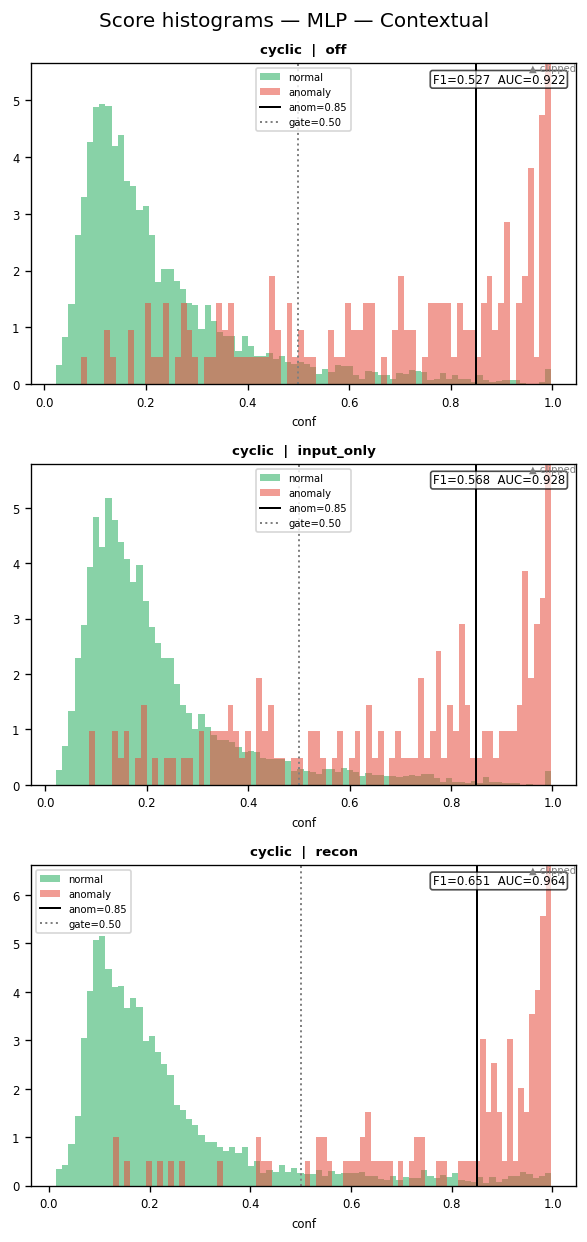

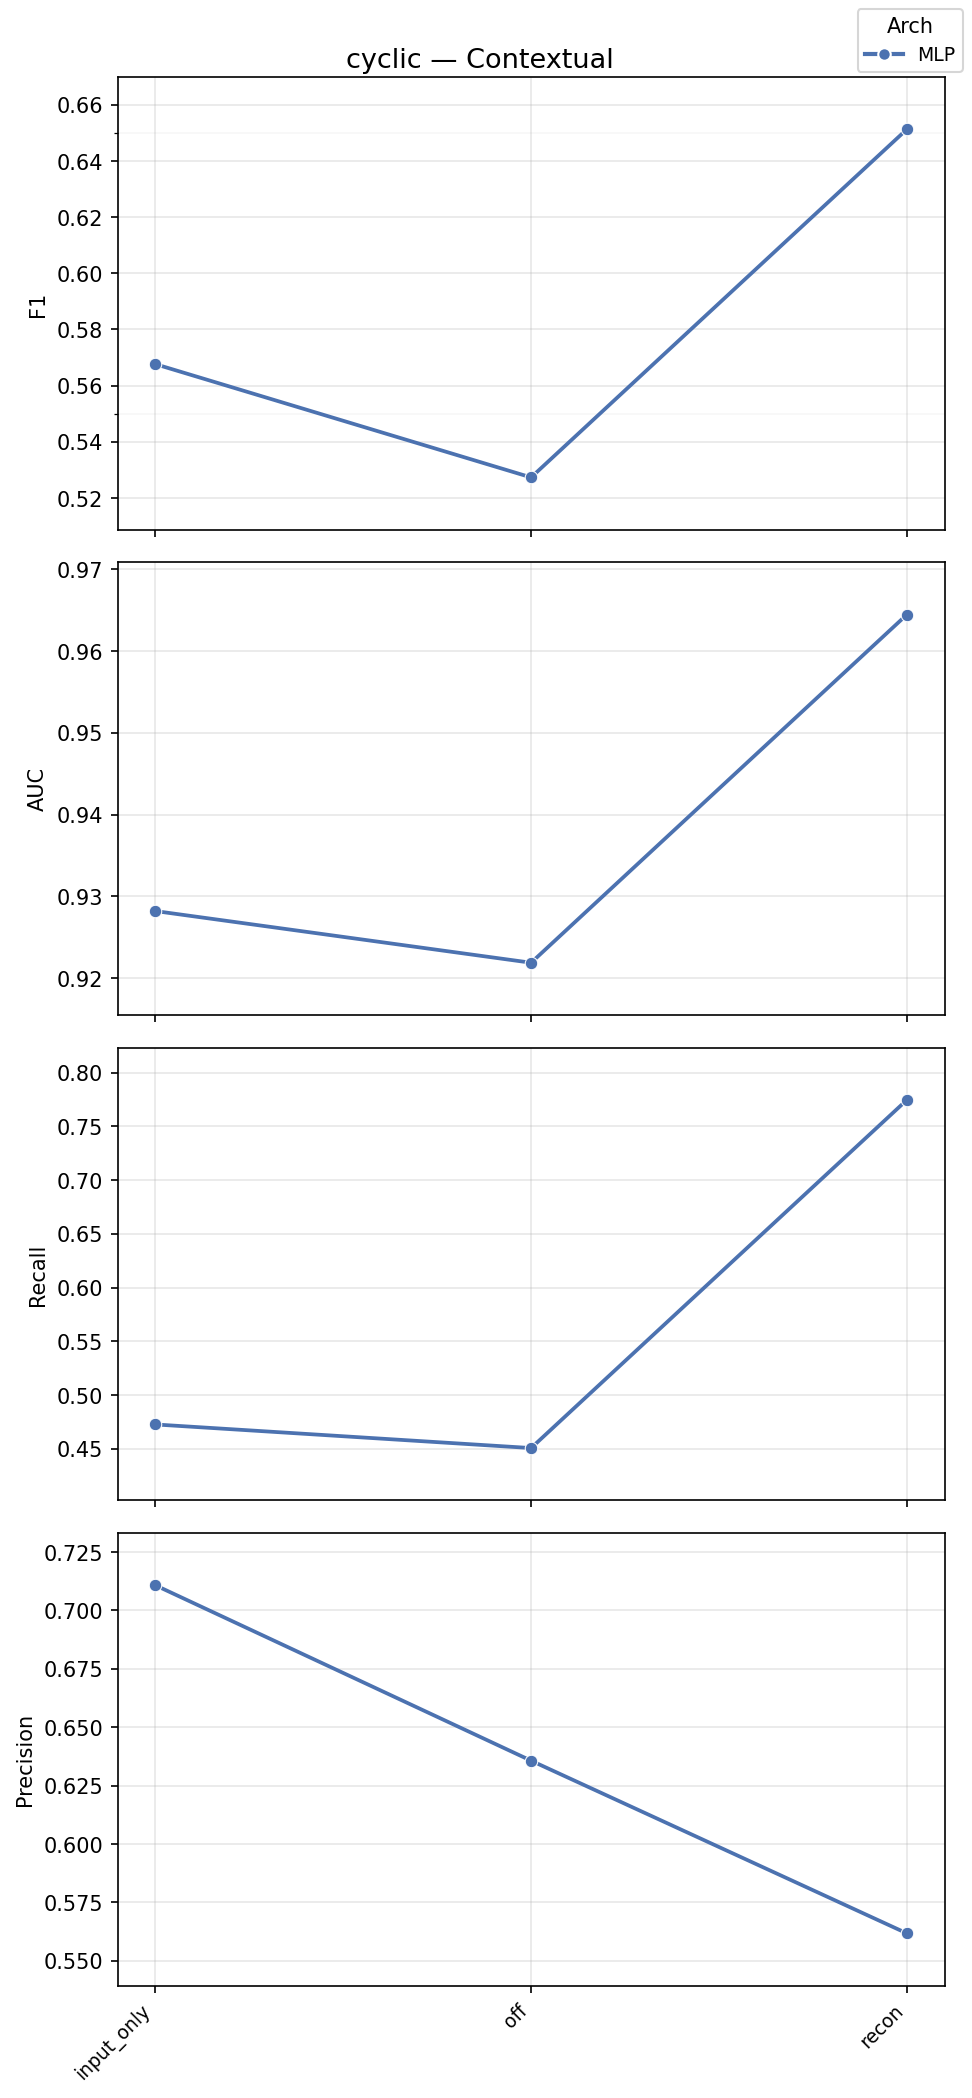

In [6]:
# Display the key comparison plot(s) inline
import glob
from IPython.display import Image, display

print("Score histograms (normal vs anomaly) and F1-vs-variant line plot:")
for p in sorted(glob.glob("runs/regression/case02_cyclic_features/cross_compare/contextual/score_hist_MLP.png")):
    display(Image(filename=p))
for p in sorted(glob.glob("runs/regression/case02_cyclic_features/cross_compare/contextual/section_lines_cyclic.png")):
    display(Image(filename=p))

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every result reported in the thesis. It uses a shorter ERA5 interval and shared reduced-run settings so that readers can execute it on Colab.

Differences from the full thesis metrics are expected. Conclusions should be based on the direction and consistency of the comparison rather than exact numerical agreement.

For the complete experiment definitions, consult the thesis section associated with Table 4.23 and Figure 4.15, together with the YAML configuration files used by this suite.
